In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

AttributeError: module 'pyarrow' has no attribute '__version__'

In [ ]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

In [ ]:
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [ ]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [ ]:
#Numeric Features
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [ ]:
#Categorical Features
df.describe(include='object')

C:\Users\Krrish_R\AppData\Local\Temp\ipykernel_13852\1865492505.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"33.964131, -118.272783",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


In [ ]:
#Null values
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [ ]:
(df.isnull().sum()/len(df))*100


CustomerID            0.000000
Count                 0.000000
Country               0.000000
State                 0.000000
City                  0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
Longitude             0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Internet Service      0.000000
Online Security       0.000000
Online Backup         0.000000
Device Protection     0.000000
Tech Support          0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Monthly Charges       0.000000
Total Charges         0.000000
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
Churn Re

In [ ]:
#Duplicate Check 
df.duplicated().sum()


np.int64(0)

In [ ]:
#Dependent Variable
df['Churn Value'].value_counts()


Churn Value
0    5174
1    1869
Name: count, dtype: int64

<Axes: xlabel='Churn Value', ylabel='count'>

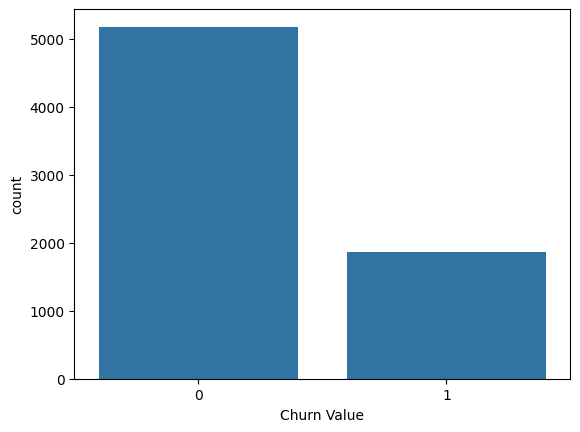

In [ ]:
sns.countplot(data=df, x="Churn Value")

In [ ]:
#Percentage
df["Churn Value"].value_counts(normalize=True)*100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Dataset has 7043 rows each row is a unique customer

target variable is Churn Label

there are 33 columns

No missing values

No duplicates 

target appear imbalanced (
    0= 73.463013
    1= 26.536987)




In [ ]:
#Removing columns to prevent Data Leakage

df.drop(['Churn Label','Churn Score'],axis=1,inplace=True)



In [ ]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Value             2
CLTV                 3438
Churn Reason           20
dtype: int64

In [ ]:
#Removing other unecessary columns and constant columns 
df.drop([
        'CLTV',
       'Churn Reason',
       'Count',
        'Country', 
        'State',
        'CustomerID',
        'City',
        'Zip Code',
       'Lat Long', 
       'Latitude', 
       'Longitude'
       ],
       axis=1,
       inplace=True)

In [ ]:
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

<Axes: xlabel='Tenure Months', ylabel='Count'>

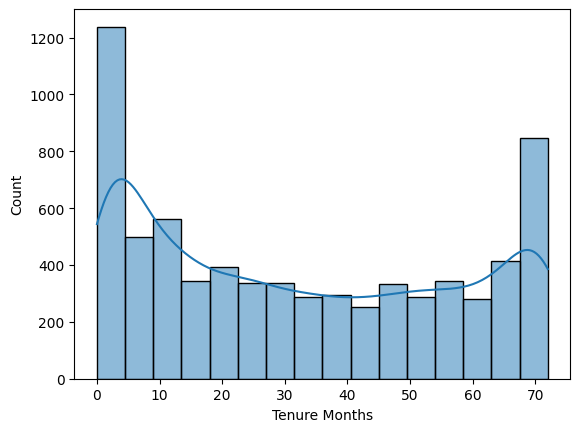

In [ ]:
sns.histplot(df["Tenure Months"], kde=True)

<Axes: xlabel='Monthly Charges'>

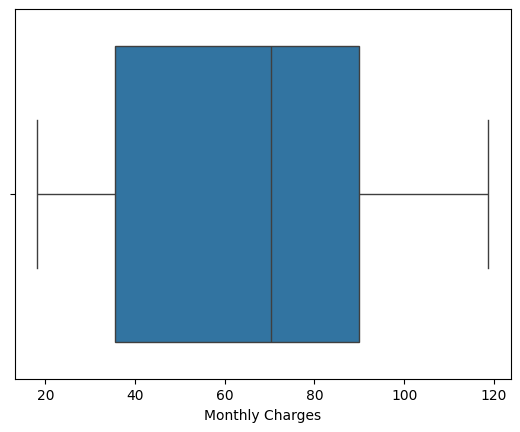

In [ ]:
sns.boxplot(x=df["Monthly Charges"])

C:\Users\Krrish_R\AppData\Local\Temp\ipykernel_13852\2625394955.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


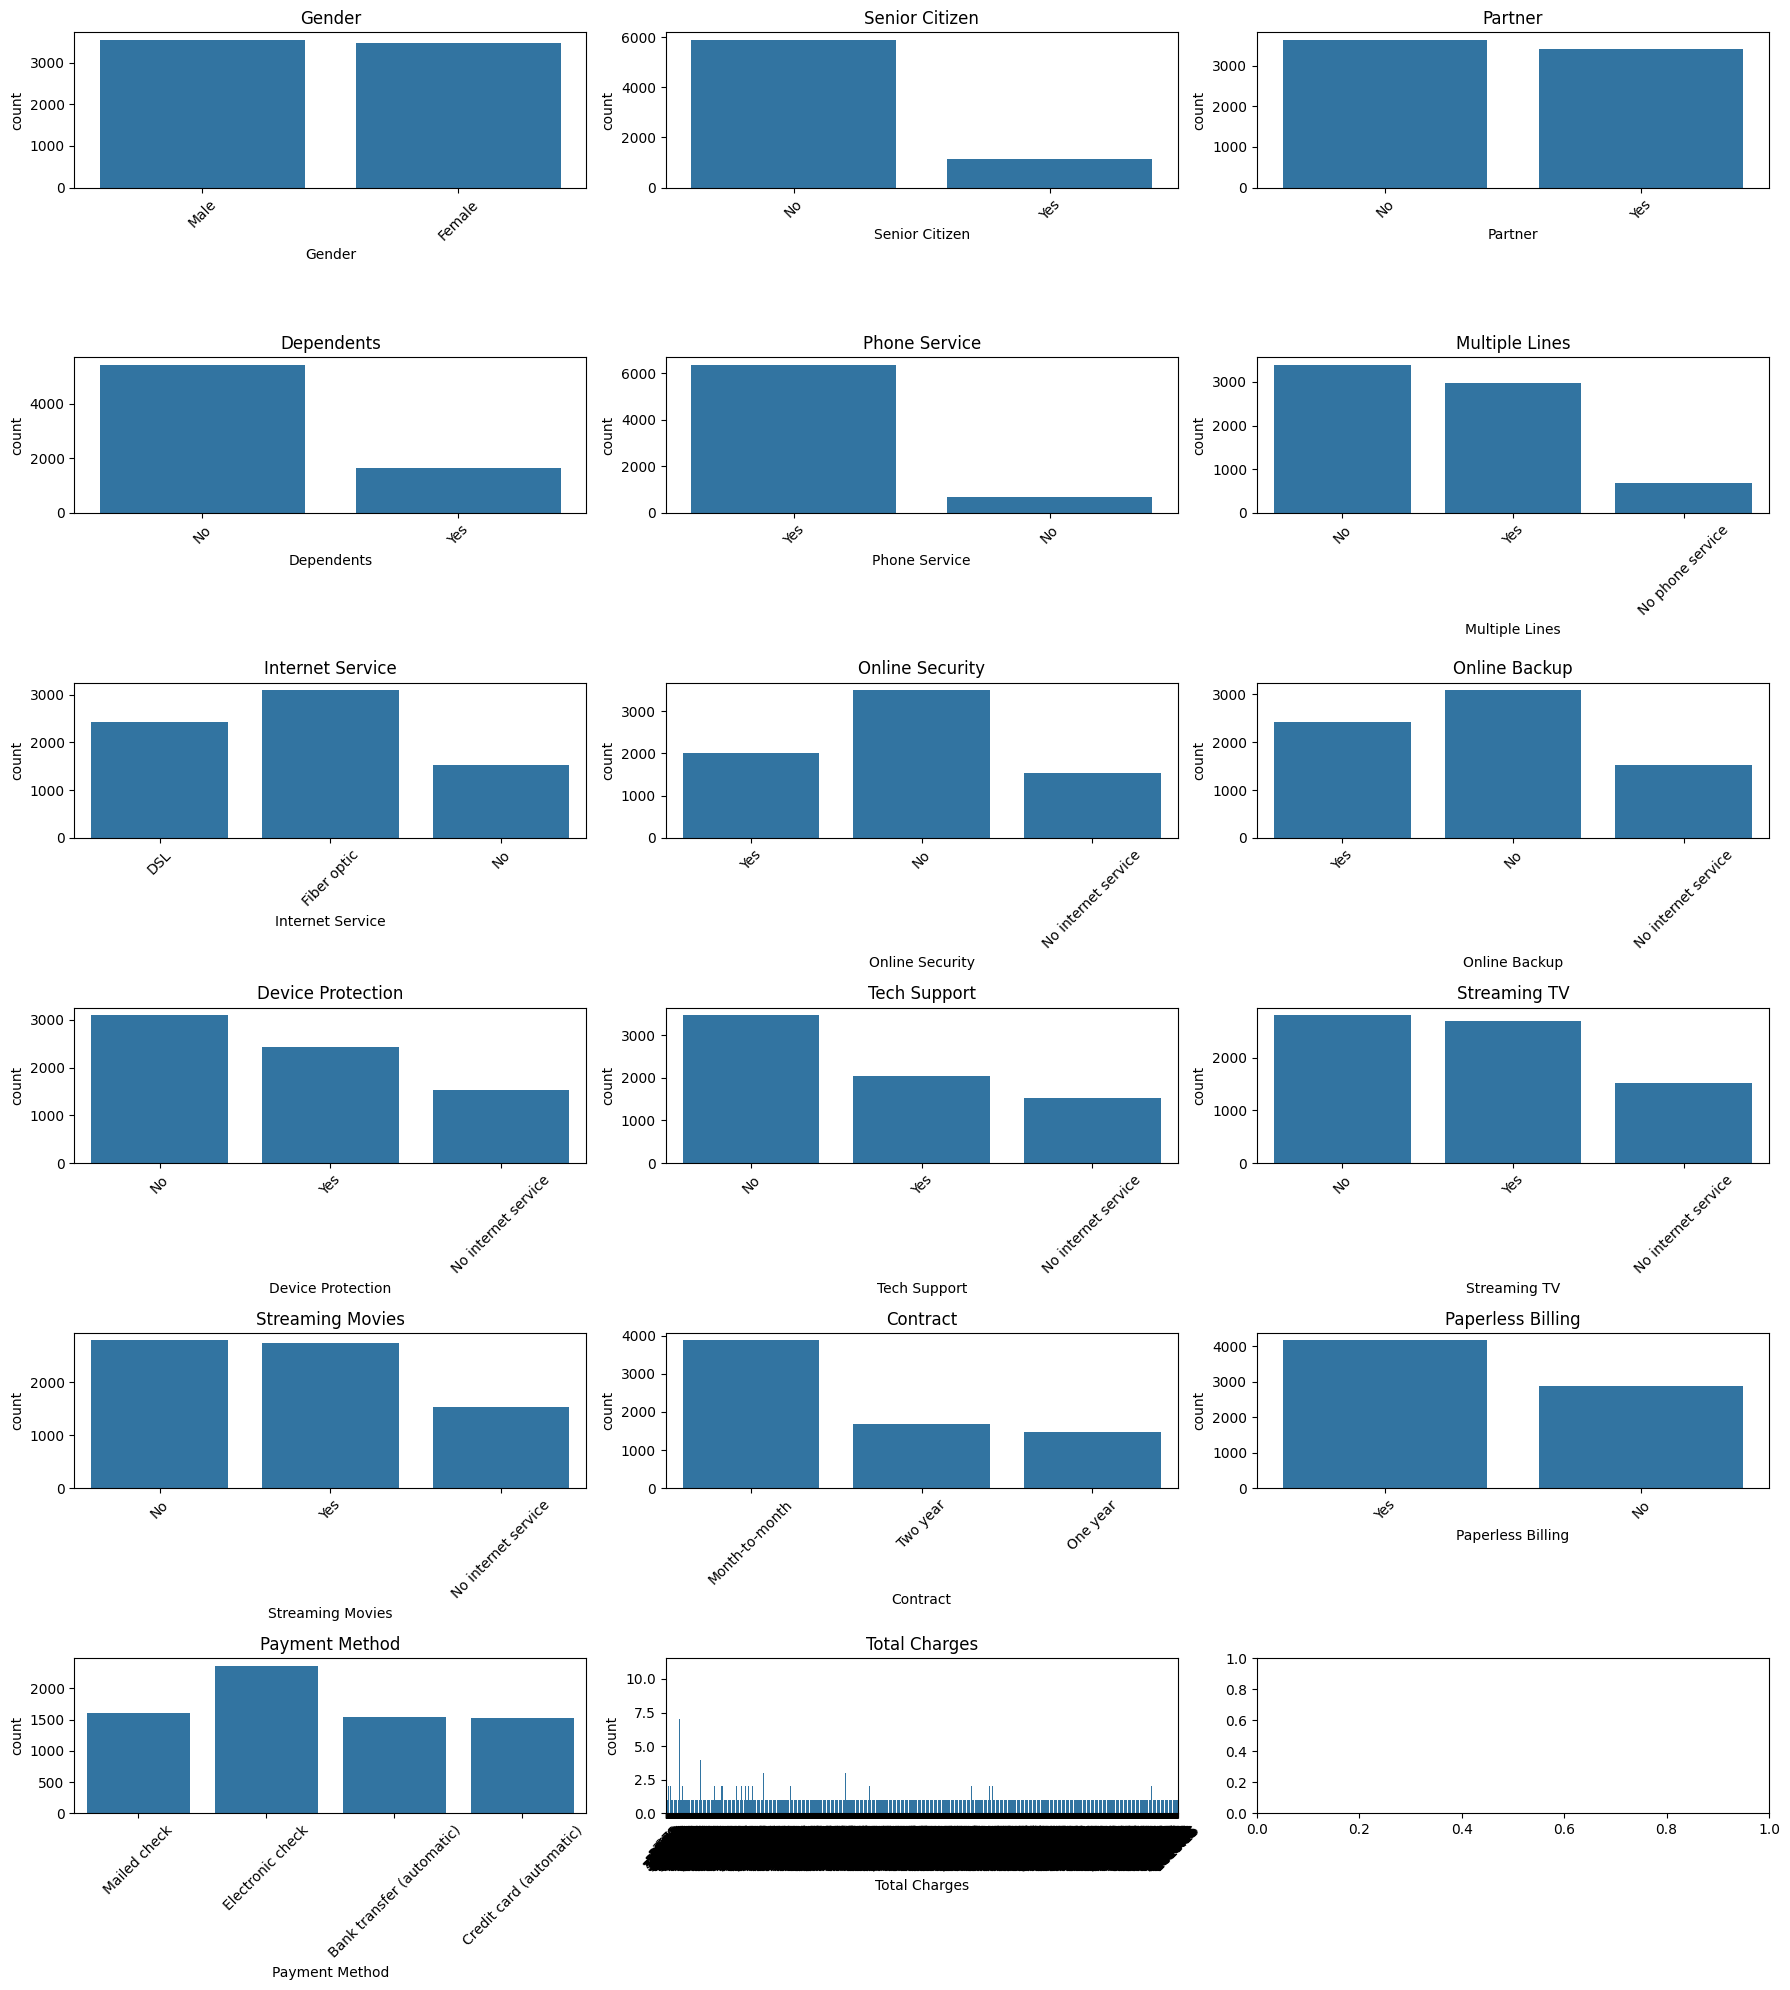

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
fig, axes = plt.subplots(6, 3, figsize=(18, 20))

axes = axes.flatten()

for i, feature in enumerate(cat_cols):
    sns.countplot(data=df, x=feature, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   str    
 1   Senior Citizen     7043 non-null   str    
 2   Partner            7043 non-null   str    
 3   Dependents         7043 non-null   str    
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   str    
 6   Multiple Lines     7043 non-null   str    
 7   Internet Service   7043 non-null   str    
 8   Online Security    7043 non-null   str    
 9   Online Backup      7043 non-null   str    
 10  Device Protection  7043 non-null   str    
 11  Tech Support       7043 non-null   str    
 12  Streaming TV       7043 non-null   str    
 13  Streaming Movies   7043 non-null   str    
 14  Contract           7043 non-null   str    
 15  Paperless Billing  7043 non-null   str    
 16  Payment Method     7043 non-null   

In [ ]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: str

In [ ]:
df[df["Total Charges"].str.strip() == ""]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,0
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,0
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,0
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,0
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,0
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,0
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,0
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,0
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,0
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,0


In [ ]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce" #Converts non numeric values to NaN
)

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
#Checking missing data rows
df.loc[
    df["Total Charges"].isna()
]
#Tenue is 0 that is why so we fill na as 0

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

Bivariate Analysis

In [ ]:
#Numerical Features vs Target Features
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

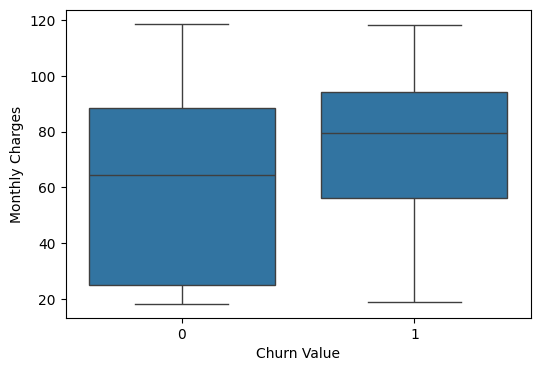

In [ ]:
#Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(
    data=df,
    x="Churn Value",
    y="Monthly Charges"
)
plt.show()



<Axes: xlabel='Monthly Charges', ylabel='Count'>

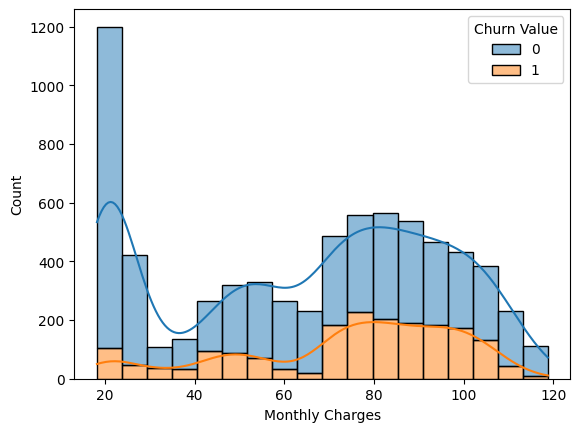

In [ ]:
sns.histplot(
    data=df,
    x="Monthly Charges",
    hue="Churn Value",
    kde=True,
    multiple="stack"
)

<Axes: xlabel='Contract', ylabel='count'>

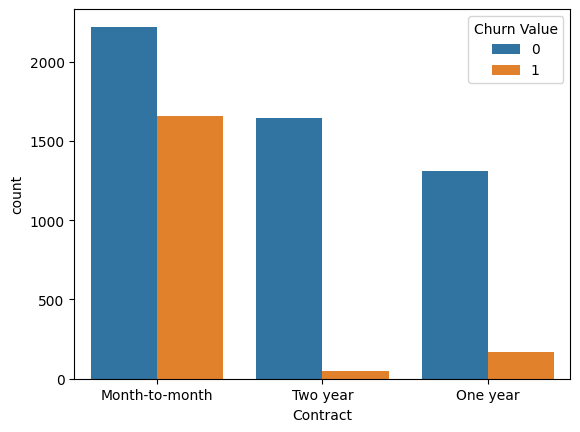

In [ ]:
#Categorical Features vs Target
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Value"
)


<Axes: xlabel='Gender', ylabel='count'>

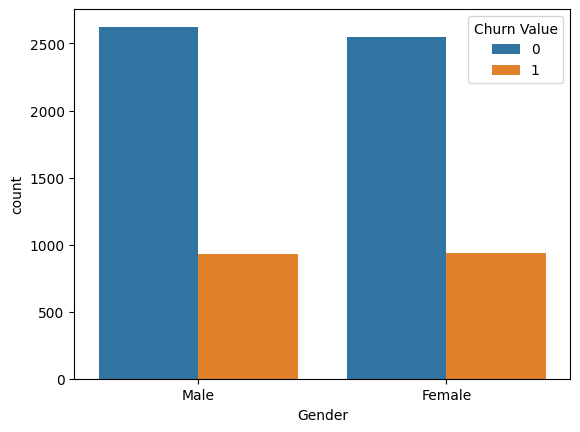

In [ ]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Value"
)

<Axes: xlabel='Senior Citizen', ylabel='count'>

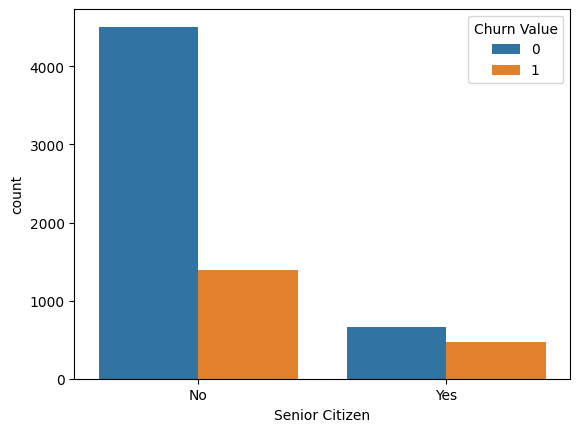

In [ ]:
sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Value"
)

<Axes: xlabel='Partner', ylabel='count'>

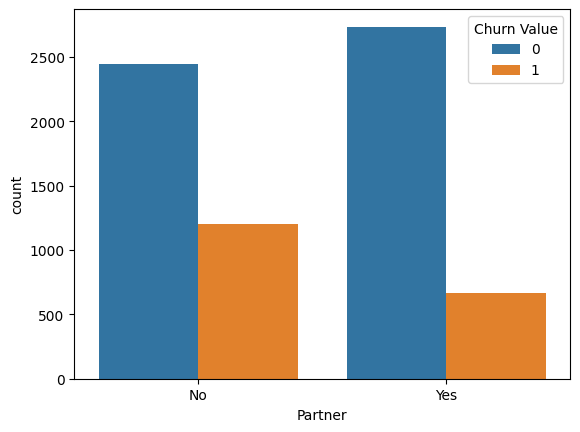

In [ ]:
sns.countplot(
    data=df,
    x="Partner",
    hue="Churn Value"
)

<Axes: xlabel='Dependents', ylabel='count'>

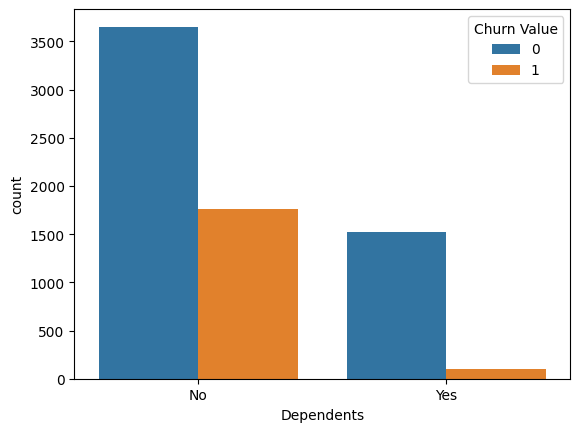

In [ ]:
sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn Value"
)

<Axes: xlabel='Phone Service', ylabel='count'>

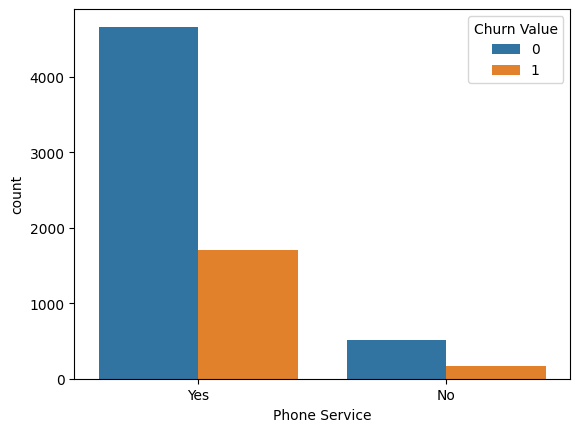

In [ ]:
sns.countplot(
    data=df,
    x="Phone Service",
    hue="Churn Value"
)

<Axes: xlabel='Multiple Lines', ylabel='count'>

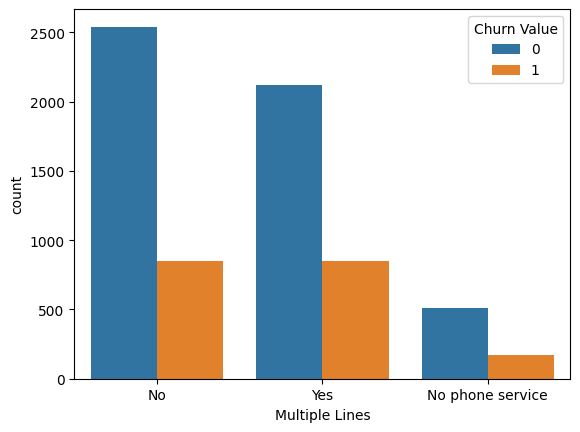

In [ ]:
sns.countplot(
    data=df,
    x="Multiple Lines",
    hue="Churn Value"
)

<Axes: xlabel='Multiple Lines', ylabel='count'>

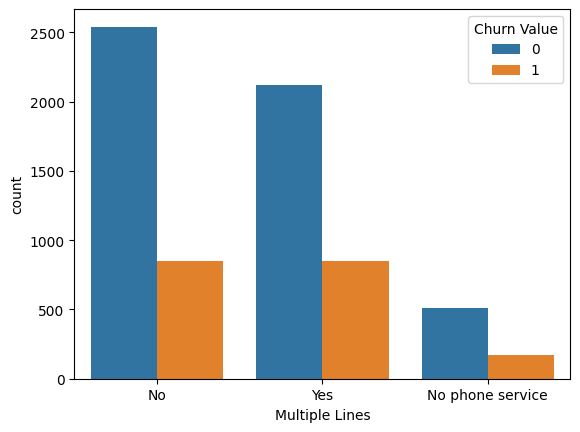

In [ ]:
sns.countplot(
    data=df,
    x="Multiple Lines",
    hue="Churn Value"
)

<Axes: xlabel='Internet Service', ylabel='count'>

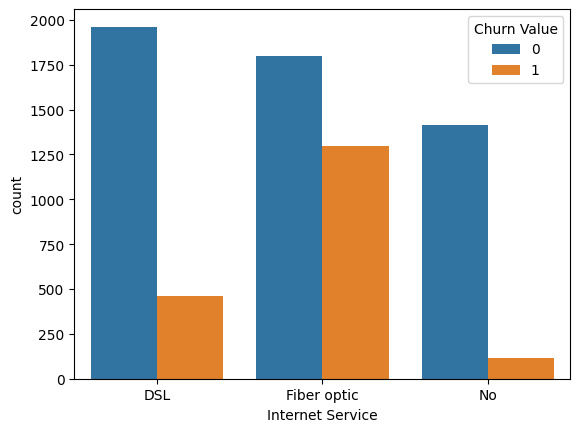

In [ ]:
sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Value"
)

<Axes: xlabel='Online Security', ylabel='count'>

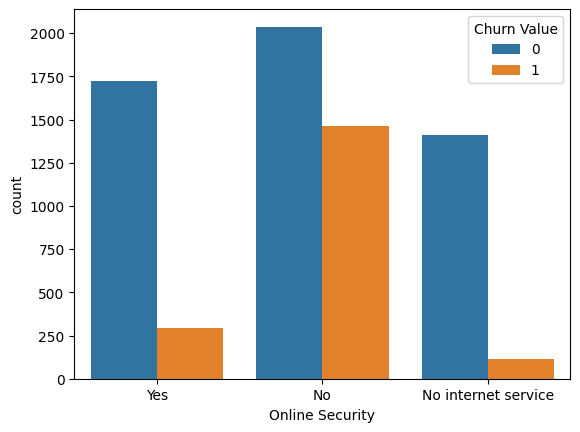

In [ ]:
sns.countplot(
    data=df,
    x="Online Security",
    hue="Churn Value"
)

<Axes: xlabel='Online Backup', ylabel='count'>

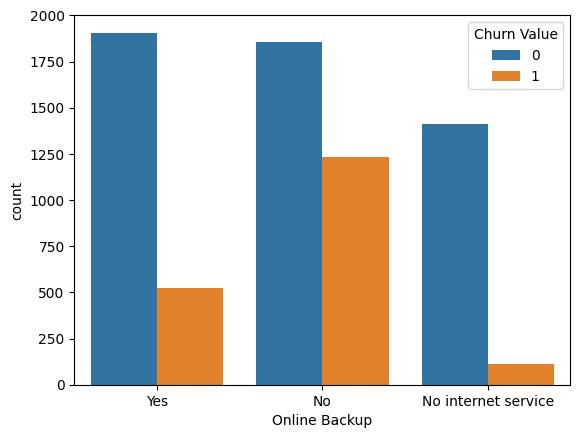

In [ ]:
sns.countplot(
    data=df,
    x="Online Backup",
    hue="Churn Value"
)

<Axes: xlabel='Device Protection', ylabel='count'>

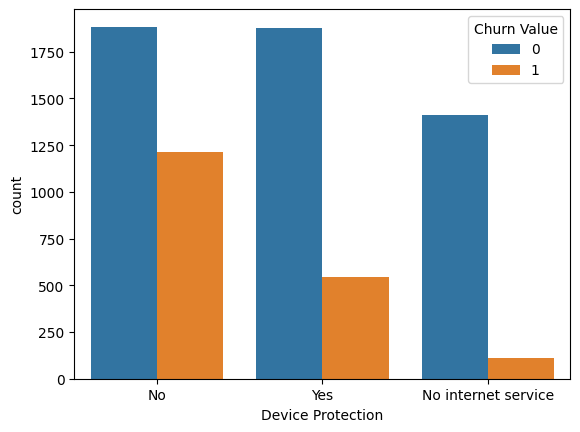

In [ ]:
sns.countplot(
    data=df,
    x="Device Protection",
    hue="Churn Value"
)

<Axes: xlabel='Tech Support', ylabel='count'>

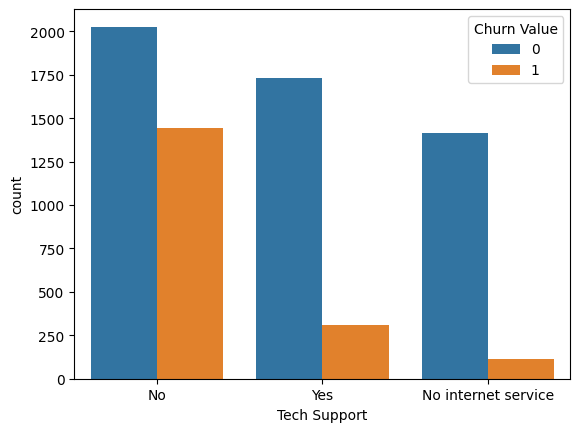

In [ ]:
sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Value"
)

<Axes: xlabel='Streaming TV', ylabel='count'>

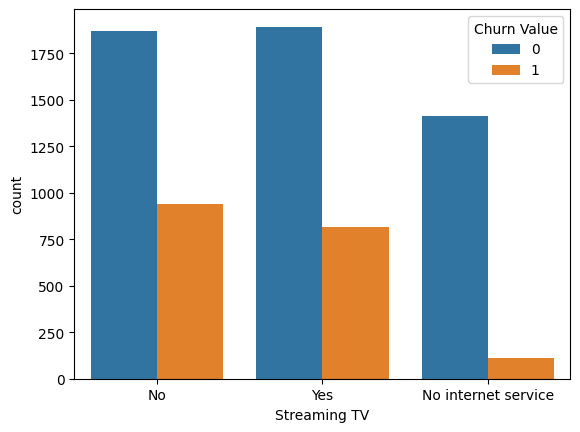

In [ ]:
sns.countplot(
    data=df,
    x="Streaming TV",
    hue="Churn Value"
)

<Axes: xlabel='Streaming Movies', ylabel='count'>

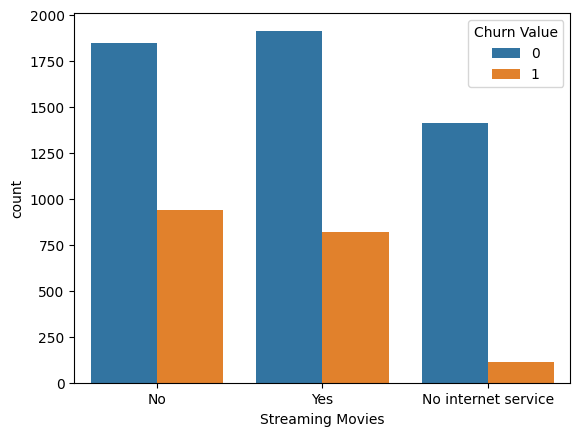

In [ ]:
sns.countplot(
    data=df,
    x="Streaming Movies",
    hue="Churn Value"
)

<Axes: xlabel='Paperless Billing', ylabel='count'>

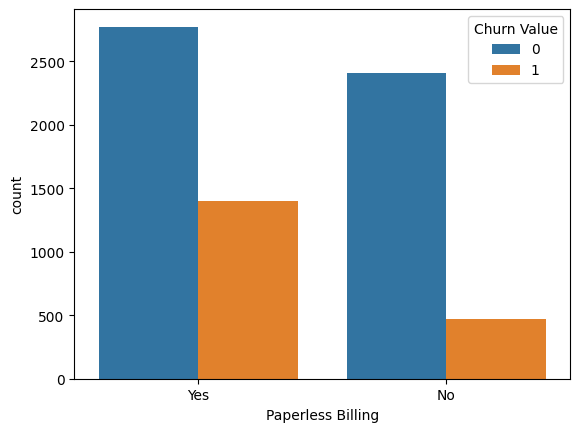

In [ ]:
sns.countplot(
    data=df,
    x="Paperless Billing",
    hue="Churn Value"
)

<Axes: xlabel='Payment Method', ylabel='count'>

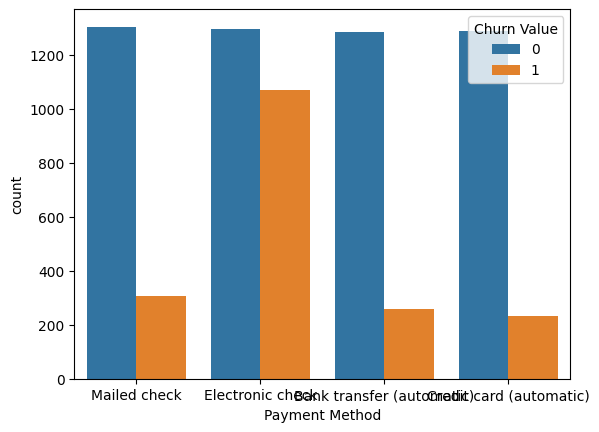

In [ ]:
sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Value"
)



Note: The above plots show absolute customer counts. To avoid misleading conclusions due to different category sizes, churn percentages were additionally calculated using normalized cross-tabulations before drawing final business conclusions.

In [ ]:
cat_cols = [
    'Contract',
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Paperless Billing',
    'Payment Method'
]

for col in cat_cols:
    print(f"\n{'='*60}")
    print(col)
    display(
        pd.crosstab(
            df[col],
            df["Churn Value"],
            normalize="index"
        ).round(3) * 100
    )


Contract


Churn Value,0,1
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8



Gender


Churn Value,0,1
Gender,,
Female,73.1,26.9
Male,73.8,26.2



Senior Citizen


Churn Value,0,1
Senior Citizen,,
No,76.4,23.6
Yes,58.3,41.7



Partner


Churn Value,0,1
Partner,,
No,67.0,33.0
Yes,80.3,19.7



Dependents


Churn Value,0,1
Dependents,,
No,67.4,32.6
Yes,93.5,6.5



Phone Service


Churn Value,0,1
Phone Service,,
No,75.1,24.9
Yes,73.3,26.7



Multiple Lines


Churn Value,0,1
Multiple Lines,,
No,75.0,25.0
No phone service,75.1,24.9
Yes,71.4,28.6



Internet Service


Churn Value,0,1
Internet Service,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4



Online Security


Churn Value,0,1
Online Security,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6



Online Backup


Churn Value,0,1
Online Backup,,
No,60.1,39.9
No internet service,92.6,7.4
Yes,78.5,21.5



Device Protection


Churn Value,0,1
Device Protection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5



Tech Support


Churn Value,0,1
Tech Support,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2



Streaming TV


Churn Value,0,1
Streaming TV,,
No,66.5,33.5
No internet service,92.6,7.4
Yes,69.9,30.1



Streaming Movies


Churn Value,0,1
Streaming Movies,,
No,66.3,33.7
No internet service,92.6,7.4
Yes,70.1,29.9



Paperless Billing


Churn Value,0,1
Paperless Billing,,
No,83.7,16.3
Yes,66.4,33.6



Payment Method


Churn Value,0,1
Payment Method,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


In [ ]:
#Conclusions
"""
Contract Type > Month-to-month customers churn significantly more than long-term contract customers.

Internet Service > Fiber optic customers exhibit the highest churn rate.

Tech Support > Customers without technical support are much more likely to churn.

Online Security > Lack of online security is strongly associated with higher churn.

Payment Method > Customers paying through Electronic Check churn considerably more than those using automatic payment methods.

Partner and Dependents > Customers without partners or dependents have noticeably higher churn rates.

Senior Citizen > Senior citizens are more likely to churn than non-senior customers.

On the other hand, Gender, Phone Service, Multiple Lines, Streaming TV, and Streaming Movies show relatively little association with churn and may contribute less to the predictive model.
"""

'\nContract Type > Month-to-month customers churn significantly more than long-term contract customers.\n\nInternet Service > Fiber optic customers exhibit the highest churn rate.\n\nTech Support > Customers without technical support are much more likely to churn.\n\nOnline Security > Lack of online security is strongly associated with higher churn.\n\nPayment Method > Customers paying through Electronic Check churn considerably more than those using automatic payment methods.\n\nPartner and Dependents > Customers without partners or dependents have noticeably higher churn rates.\n\nSenior Citizen > Senior citizens are more likely to churn than non-senior customers.\n\nOn the other hand, Gender, Phone Service, Multiple Lines, Streaming TV, and Streaming Movies show relatively little association with churn and may contribute less to the predictive model.\n'

Feature Engineering

In [ ]:
#Making Tenure month to tenure groups to have only 4 bins

df["Tenure Group"] = pd.cut(
    df["Tenure Months"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ],
    include_lowest=True
)


In [ ]:
#There are a lot of additional services and using them shows less churn so we add number of these additional services taken

services = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies"
]

df["Total Services"] = (
    df[services]
      .eq("Yes")
      .sum(axis=1)
)

In [ ]:
#Some people have automatic payments and some mannually make payments so they can be separated
df["Automatic Payment"] = (
    df["Payment Method"]
      .str.contains("automatic")
      .map({True:"Yes", False:"No"})
)


In [ ]:
#Type of internet does not really matter but having internet does 
df["Has Internet"] = (
    df["Internet Service"] != "No"
).map({True:"Yes",False:"No"})

In [ ]:
#Partner and dependents can be combined into weather the person lives alone or not
df["Lives Alone"] = (
    (df["Partner"]=="No") &
    (df["Dependents"]=="No")
).map({True:"Yes",False:"No"})

In [ ]:
df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Tenure Group,Total Services,Automatic Payment,Has Internet,Lives Alone
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,1,0-12 Months,2,No,Yes,Yes
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,1,0-12 Months,0,No,Yes,No
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,99.65,820.50,1,0-12 Months,3,No,Yes,No
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Electronic check,104.80,3046.05,1,25-48 Months,4,No,Yes,No
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Bank transfer (automatic),103.70,5036.30,1,49-72 Months,4,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,Yes,Bank transfer (automatic),21.15,1419.40,0,49-72 Months,0,Yes,No,Yes
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Mailed check,84.80,1990.50,0,13-24 Months,5,No,Yes,No
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Credit card (automatic),103.20,7362.90,0,49-72 Months,4,Yes,Yes,No
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,Yes,Electronic check,29.60,346.45,0,0-12 Months,1,No,Yes,No


Feature Selection and Preprocessing

In [ ]:
#Dependent feature
y=df['Churn Value']

In [ ]:
#Independent Feature
X=df.drop(columns=["Churn Value"])

In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y #Maintains same ratio in test data as training data
)

In [ ]:
cat_features = X_train.select_dtypes(include="object").columns

num_features = X_train.select_dtypes(include=["int64", "float64"]).columns

C:\Users\Krrish_R\AppData\Local\Temp\ipykernel_13852\1274553420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(include="object").columns


In [ ]:
#Transformers
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"#Unknown requests will not throw error
)



#Column transformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [ ]:
#Implementing pipeline to easily preprocess ,train and predict
from sklearn.pipeline import Pipeline




In [ ]:
#Linear Regression
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),#Transforms the data
        ("classifier", LogisticRegression())#Trains model using LinerarReg
    ]
)

In [ ]:
pipeline.fit(X_train,y_train) #Performs transformations and trains logistic regression model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
#Importing models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier


In [ ]:
#Dictionary of models 
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [ ]:
#Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
#Results
results=[]

In [ ]:
from sklearn.pipeline import Pipeline

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

In [ ]:
#Better visualisation of the results 
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,Gradient Boosting,0.799858,0.654362,0.521390,0.580357,0.851646
0,Logistic Regression,0.799858,0.636905,0.572193,0.602817,0.851128
5,AdaBoost,0.800568,0.659794,0.513369,0.577444,0.847400
7,XGBoost,0.779986,0.600000,0.513369,0.553314,0.832397
4,Random Forest,0.794890,0.641196,0.516043,0.571852,0.831748
2,SVM,0.803407,0.664407,0.524064,0.585949,0.816319
1,KNN,0.768630,0.565934,0.550802,0.558266,0.782703
3,Decision Tree,0.724627,0.482051,0.502674,0.492147,0.653272


Assuming that the company do not want to miss an actual churned customer so we give more priority to recall in selecting best model for hyperparameter tuning along with roc-auc score


In [ ]:
#HyperParameter Tuning
#Parameters for each model
lr_params = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

gb_params = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [3, 5, 7],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__subsample": [0.8, 1.0]
}

ada_params = {
    "classifier__n_estimators": [50, 100, 200, 300],
    "classifier__learning_rate": [0.01, 0.1, 0.5, 1.0]
}

In [ ]:
from sklearn.pipeline import Pipeline

models_to_tune = {
    "Logistic Regression": (
        LogisticRegression(random_state=42),
        lr_params
    ),
    
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        gb_params
    ),
    
    "AdaBoost": (
        AdaBoostClassifier(random_state=42),
        ada_params
    )
}

In [ ]:
best_models = {}
best_params = {}
best_scores = {}

In [ ]:
#Looping through every model
from sklearn.model_selection import RandomizedSearchCV

for name, (model, params) in models_to_tune.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=20,
        cv=5,
        scoring="roc_auc",
        random_state=42,
        n_jobs=-1,
        verbose=2
    )

    random_search.fit(X_train, y_train)

    best_models[name] = random_search.best_estimator_
    best_params[name] = random_search.best_params_
    best_scores[name] = random_search.best_score_

    print(f"\n{name}")
    print("Best Parameters:", random_search.best_params_)
    print("Best CV ROC-AUC:", random_search.best_score_)

c:\Users\Krrish_R\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\Krrish_R\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Logistic Regression
Best Parameters: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__C': 100}
Best CV ROC-AUC: 0.8609664637322855
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Gradient Boosting
Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__min_samples_split': 10, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05}
Best CV ROC-AUC: 0.8628110169692358
Fitting 5 folds for each of 16 candidates, totalling 80 fits


c:\Users\Krrish_R\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 16 is smaller than n_iter=20. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



AdaBoost
Best Parameters: {'classifier__n_estimators': 300, 'classifier__learning_rate': 1.0}
Best CV ROC-AUC: 0.8596992071643086


In [ ]:
#Testing tuned models on test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

final_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

final_results = pd.DataFrame(final_results)

final_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Gradient Boosting,0.806955,0.674658,0.526738,0.591592,0.854456
2,AdaBoost,0.803407,0.655949,0.545455,0.595620,0.851908
0,Logistic Regression,0.797019,0.630178,0.569519,0.598315,0.849823


In [ ]:
#Among the tuned models, Gradient Boosting achieved the highest ROC-AUC (0.8545) and the highest accuracy (80.7%), indicating the best overall ability to distinguish between customers who churn and those who do not. Therefore, it was selected as the final model.

In [ ]:
final_model = best_models["Gradient Boosting"]

In [ ]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:,1]

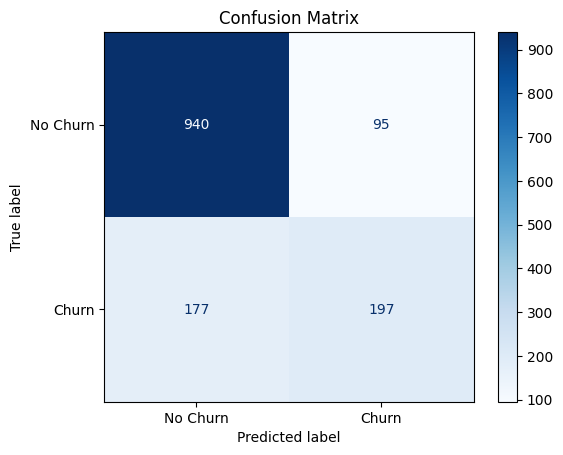

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn","Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

940 customers correctly predicted as staying  

197 customers correctly predicted as churning  

95 customers unnecessarily targeted  

177 churners missed  


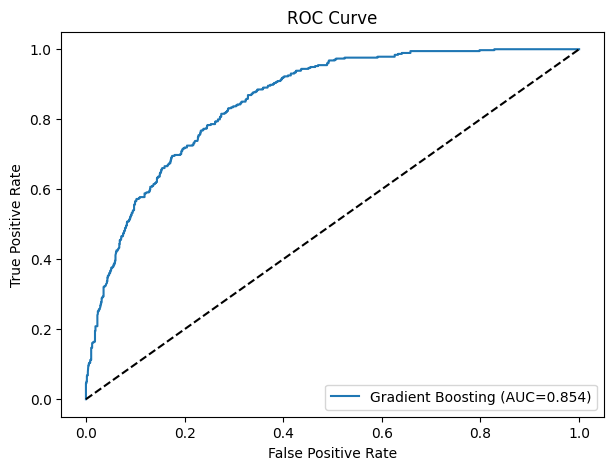

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr,
         label=f"Gradient Boosting (AUC={roc_auc_score(y_test,y_prob):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
#New feature names after Encoding
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__Tenure Months', 'num__Monthly Charges', 'num__Total Charges',
       'num__Total Services', 'cat__Gender_Male',
       'cat__Senior Citizen_Yes', 'cat__Partner_Yes',
       'cat__Dependents_Yes', 'cat__Phone Service_Yes',
       'cat__Multiple Lines_No phone service', 'cat__Multiple Lines_Yes',
       'cat__Internet Service_Fiber optic', 'cat__Internet Service_No',
       'cat__Online Security_No internet service',
       'cat__Online Security_Yes',
       'cat__Online Backup_No internet service', 'cat__Online Backup_Yes',
       'cat__Device Protection_No internet service',
       'cat__Device Protection_Yes',
       'cat__Tech Support_No internet service', 'cat__Tech Support_Yes',
       'cat__Streaming TV_No internet service', 'cat__Streaming TV_Yes',
       'cat__Streaming Movies_No internet service',
       'cat__Streaming Movies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__Paperless Billing_Yes',
       'cat__Payment Method_Credit card (auto

In [ ]:
gb_model = final_model.named_steps["classifier"]
gb_model

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``